<a href="https://colab.research.google.com/github/AtulSomkuwar/ADAS_EV_IN_MLP/blob/main/ADAS_IN_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ADAS_EV/ADAS_EV_Dataset.csv")
df


,timestamp,speed_kmh,acceleration_mps2,brake_intensity,battery_level,energy_consumption,regen_braking_usage,lane_deviation,obstacle_distance,traffic_density,weather_condition,road_type,steering_angle,reaction_time,ADAS_output
0,2023-01-01 00:00:00,44.944814,-0.758155,0.729998,65.623734,0.667933,84.723658,0.966221,4.266110,41,Rainy,Highway,13.582336,2.094568,Brake
1,2023-01-01 00:00:01,114.085717,-1.002527,0.184512,48.632783,0.280154,49.451704,1.524408,82.850462,23,Foggy,Urban,-11.512973,2.318870,Lane Correct
2,2023-01-01 00:00:02,87.839273,-1.943077,0.346640,96.627360,0.340083,19.546561,-0.147280,24.930758,12,Rainy,Rural,-22.073883,2.128859,Maintain Speed
3,2023-01-01 00:00:03,71.839018,0.643600,0.663281,25.802953,0.443275,73.664179,-0.843285,28.393736,34,Sunny,Highway,-9.533481,0.497469,Maintain Speed
4,2023-01-01 00:00:04,18.722237,-0.140255,0.482089,60.846360,0.486941,41.867814,-0.724614,22.624528,15,Sunny,Urban,2.728121,0.959573,Accelerate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-01-01 02:46:35,102.918719,2.262232,0.952275,76.633221,1.282646,96.614073,0.377586,32.212906,21,Rainy,Highway,23.120043,0.972454,Maintain Speed
9996,2023-01-01 02:46:36,107.701060,-2.719116,0.747824,77.630059,0.529768,37.323996,1.786463,37.462624,48,Rainy,Urban,16.846138,1.659061,Lane Correct
9997,2023-01-01 02:46:37,113.604950,-1.177809,0.019456,30.609096,1.523091,30.467486,1.683674,38.170174,41,Snowy,Urban,-10.221705,2.219454,Lane Correct
9998,2023-01-01 02:46:38,47.698559,-0.340080,0.401005,46.260378,1.089921,40.736253,-1.198143,12.963225,31,Rainy,Urban,-6.383439,2.137634,Maintain Speed


In [ ]:
df.shape

(10000, 15)

In [ ]:
df.isna().any()

,0
timestamp,False
speed_kmh,False
acceleration_mps2,False
brake_intensity,False
battery_level,False
energy_consumption,False
regen_braking_usage,False
lane_deviation,False
obstacle_distance,False
traffic_density,False


In [ ]:
df.drop(["timestamp"],axis = 1)

,speed_kmh,acceleration_mps2,brake_intensity,battery_level,energy_consumption,regen_braking_usage,lane_deviation,obstacle_distance,traffic_density,weather_condition,road_type,steering_angle,reaction_time,ADAS_output
0,44.944814,-0.758155,0.729998,65.623734,0.667933,84.723658,0.966221,4.266110,41,Rainy,Highway,13.582336,2.094568,Brake
1,114.085717,-1.002527,0.184512,48.632783,0.280154,49.451704,1.524408,82.850462,23,Foggy,Urban,-11.512973,2.318870,Lane Correct
2,87.839273,-1.943077,0.346640,96.627360,0.340083,19.546561,-0.147280,24.930758,12,Rainy,Rural,-22.073883,2.128859,Maintain Speed
3,71.839018,0.643600,0.663281,25.802953,0.443275,73.664179,-0.843285,28.393736,34,Sunny,Highway,-9.533481,0.497469,Maintain Speed
4,18.722237,-0.140255,0.482089,60.846360,0.486941,41.867814,-0.724614,22.624528,15,Sunny,Urban,2.728121,0.959573,Accelerate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,102.918719,2.262232,0.952275,76.633221,1.282646,96.614073,0.377586,32.212906,21,Rainy,Highway,23.120043,0.972454,Maintain Speed
9996,107.701060,-2.719116,0.747824,77.630059,0.529768,37.323996,1.786463,37.462624,48,Rainy,Urban,16.846138,1.659061,Lane Correct
9997,113.604950,-1.177809,0.019456,30.609096,1.523091,30.467486,1.683674,38.170174,41,Snowy,Urban,-10.221705,2.219454,Lane Correct
9998,47.698559,-0.340080,0.401005,46.260378,1.089921,40.736253,-1.198143,12.963225,31,Rainy,Urban,-6.383439,2.137634,Maintain Speed


<Axes: xlabel='ADAS_output', ylabel='count'>

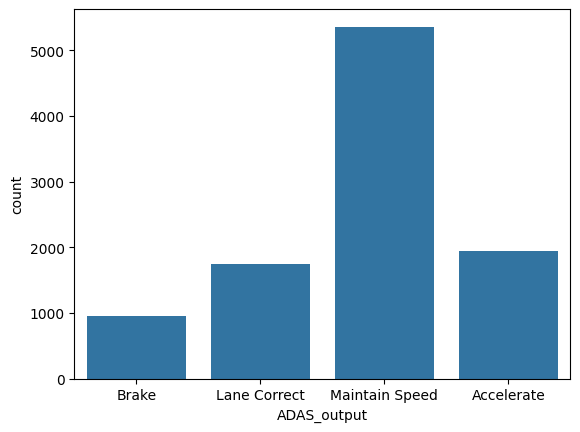

In [ ]:
sns.countplot(x='ADAS_output', data=df)

# One Hot Encoding

In [ ]:
df["ADAS_output"] = df["ADAS_output"].replace ({
    "Brake" : 0,
    "Lane Correct": 1,
    "Maintain Speed" : 2,
    "Accelerate" : 3
})

df["weather_condition"] = df["weather_condition"].replace({
    "Rainy" : 0,
    "Sunny" : 1,
    "Foggy" : 2,
    "Snowy" : 3
})

df["road_type"] = df["road_type"].replace({
    "Rural": 0,
    "Urban": 1,
    "Highway": 2
})
df


/tmp/ipykernel_1636/3878725388.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["ADAS_output"] = df["ADAS_output"].replace ({
/tmp/ipykernel_1636/3878725388.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["weather_condition"] = df["weather_condition"].replace({
/tmp/ipykernel_1636/3878725388.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `

,timestamp,speed_kmh,acceleration_mps2,brake_intensity,battery_level,energy_consumption,regen_braking_usage,lane_deviation,obstacle_distance,traffic_density,weather_condition,road_type,steering_angle,reaction_time,ADAS_output
0,2023-01-01 00:00:00,44.944814,-0.758155,0.729998,65.623734,0.667933,84.723658,0.966221,4.266110,41,0,2,13.582336,2.094568,0
1,2023-01-01 00:00:01,114.085717,-1.002527,0.184512,48.632783,0.280154,49.451704,1.524408,82.850462,23,2,1,-11.512973,2.318870,1
2,2023-01-01 00:00:02,87.839273,-1.943077,0.346640,96.627360,0.340083,19.546561,-0.147280,24.930758,12,0,0,-22.073883,2.128859,2
3,2023-01-01 00:00:03,71.839018,0.643600,0.663281,25.802953,0.443275,73.664179,-0.843285,28.393736,34,1,2,-9.533481,0.497469,2
4,2023-01-01 00:00:04,18.722237,-0.140255,0.482089,60.846360,0.486941,41.867814,-0.724614,22.624528,15,1,1,2.728121,0.959573,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-01-01 02:46:35,102.918719,2.262232,0.952275,76.633221,1.282646,96.614073,0.377586,32.212906,21,0,2,23.120043,0.972454,2
9996,2023-01-01 02:46:36,107.701060,-2.719116,0.747824,77.630059,0.529768,37.323996,1.786463,37.462624,48,0,1,16.846138,1.659061,1
9997,2023-01-01 02:46:37,113.604950,-1.177809,0.019456,30.609096,1.523091,30.467486,1.683674,38.170174,41,3,1,-10.221705,2.219454,1
9998,2023-01-01 02:46:38,47.698559,-0.340080,0.401005,46.260378,1.089921,40.736253,-1.198143,12.963225,31,0,1,-6.383439,2.137634,2


# Scaling

In [ ]:

X = df.drop(["ADAS_output","timestamp"],axis = 1)
y = df["ADAS_output"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state= 42, stratify=y)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


print('Training dataset',np.shape(X_train),np.shape(y_train))
print('Testing dataset',np.shape(X_test),np.shape(y_test))

print(y_train)

Training dataset (8000, 13) (8000,)
Testing dataset (2000, 13) (2000,)
6430    0
7112    2
1546    2
2035    2
7401    2
       ..
9269    2
7980    0
6       3
4817    2
5707    3
Name: ADAS_output, Length: 8000, dtype: int64


# MLP Backpropogation

In [ ]:
from sklearn.neural_network import MLPClassifier

model = models.Sequential([
    layers.Dense(128,activation = "relu"),
    layers.Dense(64,activation = "relu"),
    layers.Dense(32,activation = "relu"),
    layers.Dense(4,activation = "softmax")

])
model.compile (
    optimizer = 'adam',
    loss = "sparse_categorical_crossentropy",
    metrics = ['accuracy']
)

history = model.fit(
    X_train,y_train,
    validation_split = 0.2,
    epochs = 30,
    batch_size = 32,
    verbose = 1
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6647 - loss: 0.8289 - val_accuracy: 0.7344 - val_loss: 0.5752
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8184 - loss: 0.4419 - val_accuracy: 0.8531 - val_loss: 0.3479
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8758 - loss: 0.3081 - val_accuracy: 0.8775 - val_loss: 0.2845
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8922 - loss: 0.2588 - val_accuracy: 0.8894 - val_loss: 0.2550
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9100 - loss: 0.2259 - val_accuracy: 0.8975 - val_loss: 0.2391
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9156 - loss: 0.2025 - val_accuracy: 0.9056 - val_loss: 0.2132
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9261 - loss: 0.1800 - val_accuracy: 0.9112 - val_loss: 0.2066
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9373 - loss: 0.1607 - val_accuracy: 0.

In [ ]:
# PREDICTION

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


# Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

Accuracy = accuracy_score(y_test,y_pred)
print("Accuracy :",Accuracy)

Accuracy : 0.911


# Confusion Matrix

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


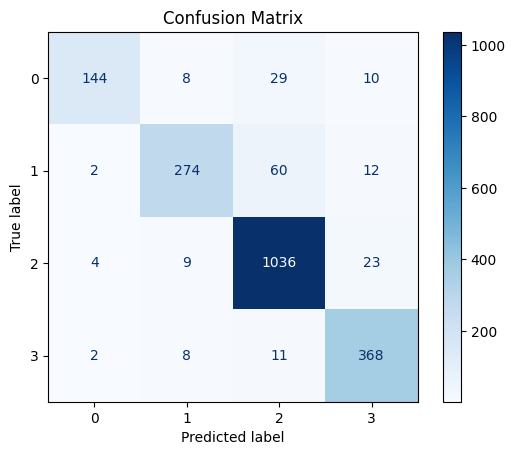

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred_probs = model.predict(X_test) # Get probability predictions
y_pred = np.argmax(y_pred_probs, axis=1) # Convert probabilities to class labels

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Loss Curve

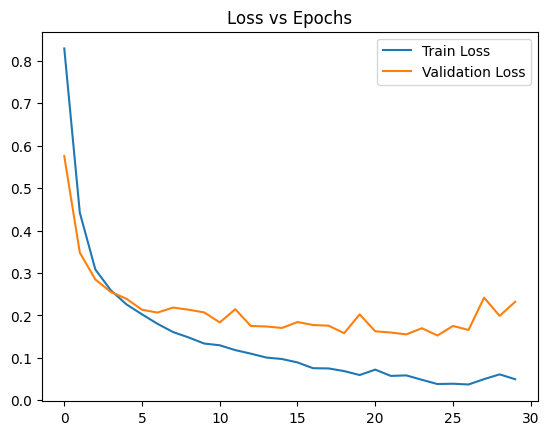

In [ ]:
# LOSS CURVE

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

# Tried various Methods to improve its accuracy

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ADAS_EV/ADAS_EV_Dataset.csv")
df

,timestamp,speed_kmh,acceleration_mps2,brake_intensity,battery_level,energy_consumption,regen_braking_usage,lane_deviation,obstacle_distance,traffic_density,weather_condition,road_type,steering_angle,reaction_time,ADAS_output
0,2023-01-01 00:00:00,44.944814,-0.758155,0.729998,65.623734,0.667933,84.723658,0.966221,4.266110,41,Rainy,Highway,13.582336,2.094568,Brake
1,2023-01-01 00:00:01,114.085717,-1.002527,0.184512,48.632783,0.280154,49.451704,1.524408,82.850462,23,Foggy,Urban,-11.512973,2.318870,Lane Correct
2,2023-01-01 00:00:02,87.839273,-1.943077,0.346640,96.627360,0.340083,19.546561,-0.147280,24.930758,12,Rainy,Rural,-22.073883,2.128859,Maintain Speed
3,2023-01-01 00:00:03,71.839018,0.643600,0.663281,25.802953,0.443275,73.664179,-0.843285,28.393736,34,Sunny,Highway,-9.533481,0.497469,Maintain Speed
4,2023-01-01 00:00:04,18.722237,-0.140255,0.482089,60.846360,0.486941,41.867814,-0.724614,22.624528,15,Sunny,Urban,2.728121,0.959573,Accelerate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-01-01 02:46:35,102.918719,2.262232,0.952275,76.633221,1.282646,96.614073,0.377586,32.212906,21,Rainy,Highway,23.120043,0.972454,Maintain Speed
9996,2023-01-01 02:46:36,107.701060,-2.719116,0.747824,77.630059,0.529768,37.323996,1.786463,37.462624,48,Rainy,Urban,16.846138,1.659061,Lane Correct
9997,2023-01-01 02:46:37,113.604950,-1.177809,0.019456,30.609096,1.523091,30.467486,1.683674,38.170174,41,Snowy,Urban,-10.221705,2.219454,Lane Correct
9998,2023-01-01 02:46:38,47.698559,-0.340080,0.401005,46.260378,1.089921,40.736253,-1.198143,12.963225,31,Rainy,Urban,-6.383439,2.137634,Maintain Speed


<Axes: xlabel='ADAS_output', ylabel='count'>

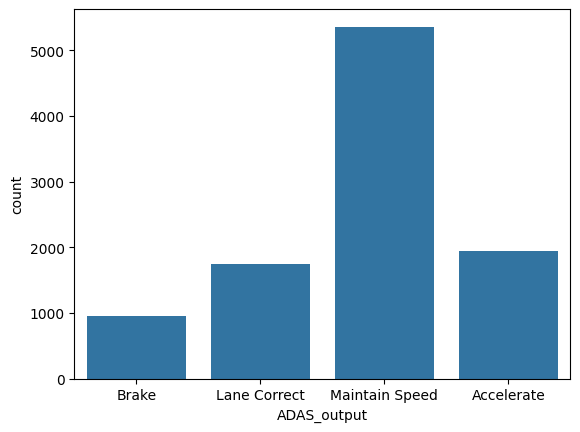

In [ ]:
sns.countplot(x='ADAS_output', data=df)

# Label Encoding

In [ ]:
df = df.drop(["timestamp"], axis=1, errors="ignore")

df["ADAS_output"] = df["ADAS_output"].replace({
    "Brake": 0,
    "Lane Correct": 1,
    "Maintain Speed": 2,
    "Accelerate": 3
})

df["weather_condition"] = df["weather_condition"].replace({
    "Rainy": 0,
    "Sunny": 1,
    "Foggy": 2,
    "Snowy": 3
})

df["road_type"] = df["road_type"].replace({
    "Highway": 0,
    "Urban": 1,
    "Rural": 2
})

/tmp/ipykernel_5323/2051039575.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["ADAS_output"] = df["ADAS_output"].replace({
/tmp/ipykernel_5323/2051039575.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["weather_condition"] = df["weather_condition"].replace({
/tmp/ipykernel_5323/2051039575.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `

<Axes: xlabel='ADAS_output', ylabel='count'>

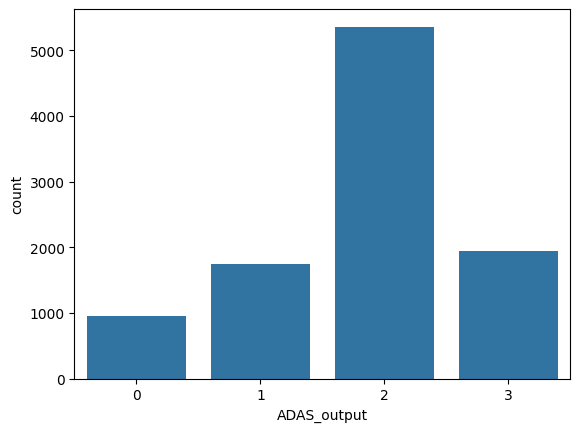

In [ ]:
sns.countplot(x='ADAS_output', data=df)

In [ ]:
X = df.drop(["ADAS_output"], axis=1)
y = df["ADAS_output"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## ADAS dataset, you have 4 classes:

Brake

Lane Correct

Maintain Speed

Accelerate

## These are usually not equally distributed.

Maintain Speed → 5000 samples  
Brake → 1500 samples  
Lane Correct → 2000 samples  
Accelerate → 1500 samples

## Problem without class weights:

Model becomes biased toward Maintain Speed,
It may ignore Brake or Accelerate,
Accuracy looks high, but real performance is poor



In [ ]:
# CLASS WEIGHTS (for imbalance classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)


Class Weights: {0: np.float64(2.6212319790301444), 1: np.float64(1.4357501794687724), 2: np.float64(0.4666355576294914), 3: np.float64(1.2836970474967908)}


# Batch Normalization → makes training stable and faster

Normalizes activations (mean ≈ 0, std ≈ 1)
Keeps values in a stable range

# Dropout → prevents overfitting so the model generalizes better
Prevents overfitting

In [ ]:
# BUILD OPTIMIZED MLP

model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='softmax')
])


#  COMPILE MODEL

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# EarlyStopping  
Watches validation loss If it stops improving for 10 epochs → stops training Without it Model may overfit

# ReduceLROnPlateau
If learning gets stuck → reduces learning rate

In [ ]:
# CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

In [ ]:
# TRAIN MODEL

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3602 - loss: 1.2680 - val_accuracy: 0.6731 - val_loss: 0.9617 - learning_rate: 5.0000e-04
Epoch 2/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5294 - loss: 0.9011 - val_accuracy: 0.7013 - val_loss: 0.7226 - learning_rate: 5.0000e-04
Epoch 3/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6197 - loss: 0.7476 - val_accuracy: 0.7069 - val_loss: 0.6740 - learning_rate: 5.0000e-04
Epoch 4/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6873 - loss: 0.6301 - val_accuracy: 0.7319 - val_loss: 0.5796 - learning_rate: 5.0000e-04
Epoch 5/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7136 - loss: 0.5682 - val_accuracy: 0.7450 - val_loss: 0.5576 - learning_rate: 5.0000e-04
Epoch 6/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7273 - loss: 0.5547 - val_accuracy: 0.7750 - val_loss: 0.4896 - learning_rate: 5.0000e-04
Epoch 7/80
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 

In [ ]:

# PREDICTION

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)


# EVALUATION

accuracy = accuracy_score(y_test, y_pred)
print("\nFinal MLP Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Final MLP Accuracy: 0.981

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       191
           1       0.97      0.98      0.97       348
           2       0.99      0.98      0.98      1072
           3       0.97      0.99      0.98       389

    accuracy                           0.98      2000
   macro avg       0.97      0.99      0.98      2000
weighted avg       0.98      0.98      0.98      2000



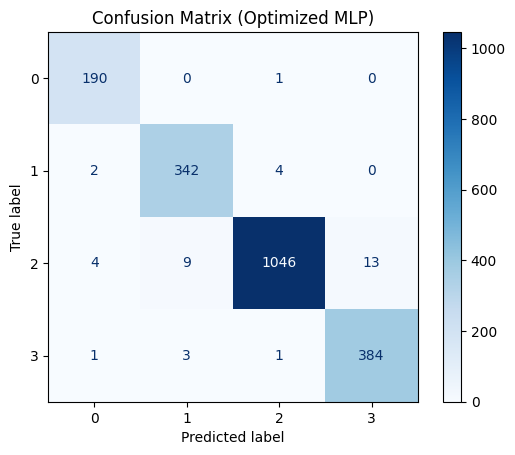

In [ ]:

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix (Optimized MLP)")
plt.show()

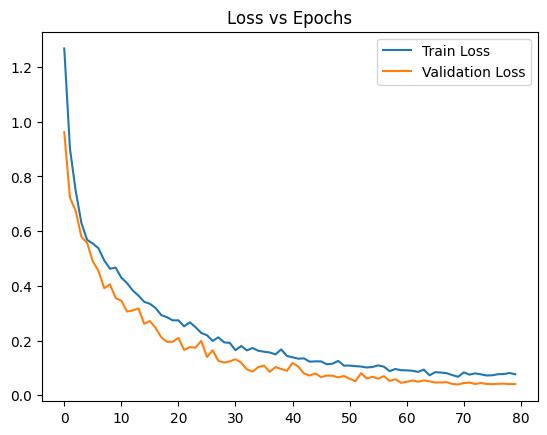

In [ ]:

# LOSS & ACCURACY CURVES

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()



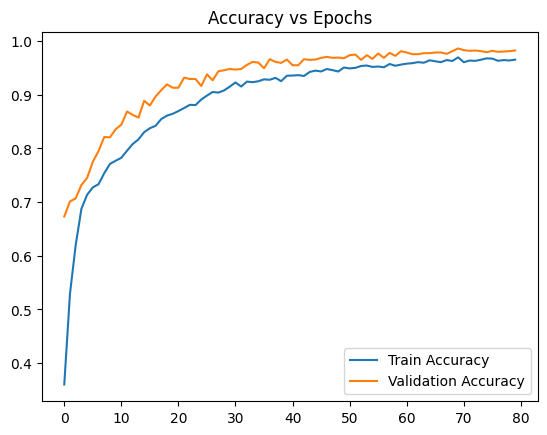

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()